# Quickstart Guide

Welcome to `pi-oplsda`! This is a robust Python toolkit for Orthogonal Partial Least Squares Discriminant Analysis (OPLS-DA), specifically designed to achieve seamless alignment with the widely used R package `ropls`.

This tutorial will guide you step-by-step through building a complete analysis pipeline. You will learn how to load data, fit an OPLS-DA model, evaluate its performance via permutation testing, and generate publication-ready diagnostic visualizations. We will use a built-in benchmark metabolomics dataset for a standard binary classification task.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import piopls
from piopls import OPLSDA, OPLSDA_Visualizer
from piopls import load_sacurine

# Print the installed version of pi-oplsda to ensure compatibility
print(f"pi-oplsda version: {piopls.__version__}")

pi-oplsda version: 0.1.2


## 1. Loading the Benchmark Dataset (Sacurine)
The `sacurine` dataset is a classic human urine metabolomics dataset containing 183 samples and 109 metabolite features. 

The target response variable `y` represents the Gender of the individuals (`M` for Male, `F` for Female). This makes our experimental setup a standard **binary classification (two-group) design**, which is the most common usecase for OPLS-DA in biomarker discovery.

In [2]:
# Load the built-in demo dataset.
# The function load_sacurine() returns four variables:
# 1. X: The feature matrix (samples x metabolites)
# 2. y: The target array (class labels for each sample)
# 3. feature_names: The names or IDs of the 109 metabolites
# 4. sample_names: The unique identifiers for the 183 samples
X, y, feature_names, sample_names = load_sacurine()

# Verify the dimensions of our loaded data
print(f"Feature matrix X shape: {X.shape}")
print(f"Target array y shape: {y.shape}")
print(f"Unique classes in y: {np.unique(y)}")

Feature matrix X shape: (183, 109)
Target array y shape: (183,)
Unique classes in y: ['F' 'M']


## 2. Binary Design: OPLS-DA Analysis
For two-group comparisons in metabolomics, **OPLS-DA** is considered the gold standard algorithm. 

Unlike standard PCA or PLS-DA, OPLS-DA effectively filters out orthogonal noise—which is the variation in the dataset that is completely unrelated to the group labels (e.g., technical batch effects or intra-group individual differences). By pushing this noise to orthogonal components, the predictive component becomes much cleaner, allowing for a more precise and interpretable identification of differential metabolites (biomarkers).

### 2.1 Perform OPLS-DA modeling and permutation testing
Here, we instantiate the `OPLSDA` model. A crucial parameter is `n_ortho` (the number of orthogonal components). 
By setting `n_ortho=None`, we instruct the model to automatically determine the optimal number of orthogonal components using Q2 heuristics via cross-validation.

After fitting the model, we perform a multi-core **Permutation Test** to statistically validate that our model is robust and not over-fitted.

In [3]:
# 1. Load DataFrame
# (In this specific example, we load directly from CSV files to demonstrate working with pandas DataFrames)
df_X = pd.read_csv("../src/piopls/data/sacurine_X.csv", index_col=[0])
df_Y = pd.read_csv("../src/piopls/data/sacurine_Y.csv", index_col=[0])
y_data = df_Y.iloc[:, 0].values 

# 2. Model configuration and computation
# cv_folds: Number of folds for cross-validation
# max_ortho: The maximum number of orthogonal components to search if n_ortho is None
# n_perms: Number of permutations for the validation test
# n_jobs: -1 uses all available CPU cores for parallel permutation testing
model_opls = OPLSDA(
    cv_folds=7,
    max_ortho=10, 
    n_perms=100, 
    n_jobs=-1
)

# Fit the OPLS-DA model to the data
model_opls.fit(df_X, y_data)

# Compute the cross-validated Q2 metric (predictive ability)
model_opls.compute_q2(df_X, y_data) 

# Execute the permutation test to evaluate the statistical significance of R2Y and Q2
perm_results = model_opls.permutation_test(
    df_X,
    y_data
)

# 3. Initialize the Visualizer
# The Visualizer consumes the fitted model and true labels to prepare the plotting environment.
# vip_threshold: The cutoff for highlighting important features in the S-Plot
# top_n_vip: The number of top features to display in the VIP bar plot
vis_opls = OPLSDA_Visualizer(
    model=model_opls, 
    y=y_data, 
    feature_names=None, 
    sample_names=None, 
    vip_threshold=1.0, 
    top_n_vip=15, 
    custom_palette=None
)

Permutation Test: 100%|██████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.82it/s]


### 2.2 Exporting Model Metrics as DataFrames
`pi-oplsda` provides a suite of methods strictly aligned with the `ropls` package to export key parameters as formatted `pandas.DataFrame` objects.

These tables are highly valuable for clinical research reports, allowing users to extract the global summary, component-wise variance explanation, sample scores, and feature selection metrics (e.g., VIP scores, Covariance, Correlation).

In [4]:
# Get a global overview of the model metadata (Matches ropls getSummaryDF)
# Displays N_Predictive, N_Ortho, cumulative R2X/R2Y/Q2, RMSEE, and permutation p-values
display(model_opls.get_model_info_df())

# Get the step-wise summary dataframe showing incremental variance explained by each component (p1, o1, o2...)
display(model_opls.get_summary_df())

# Get the model scores dataframe for samples
# Providing y_true enables the generation of the 'Match_Status' column to flag misclassifications
display(model_opls.get_scores_df(y_true=y_data))

# Get the feature selection dataframe
# Contains VIP scores, Covariance (p1), and Correlation (pcorr1), sorted by VIP in descending order
display(model_opls.get_features_df())


,N_Predictive,N_Ortho,R2X(cum),R2Y(cum),Q2(cum),RMSEE,pR2Y,pQ2
0,1,2,0.275229,0.729833,0.592026,0.258764,0.009901,0.009901


,Component,R2X,R2Y,Q2,R2X(cum),R2Y(cum),Q2(cum)
0,p1,0.098442,0.479107,0.401144,0.098442,0.479107,0.401144
1,o1,0.086129,0.189217,0.243941,0.184571,0.668324,0.547230
2,o2,0.090658,0.061509,0.098938,0.275229,0.729833,0.592026


,Sample,t_pred,t_ortho_1,t_ortho_2,True_Class,Fitted_Value,Fitted_Class,Match_Status
0,HU_011,1.582933,4.980604,-5.268184,M,0.841541,M,Matched
1,HU_014,-1.372806,1.744338,-0.892428,F,0.290528,F,Matched
2,HU_015,3.341370,3.437277,-2.477440,M,1.169351,M,Matched
3,HU_017,3.590063,0.979496,-3.557066,M,1.215713,M,Matched
4,HU_018,1.662716,-0.315585,3.628218,M,0.856414,M,Matched
...,...,...,...,...,...,...,...,...
178,HU_205,3.020039,0.185278,2.136284,M,1.109448,M,Matched
179,HU_206,-0.238014,-1.022405,3.789028,F,0.502077,M,Mismatched
180,HU_207,-4.860766,-3.253181,0.538034,F,-0.359703,F,Matched
181,HU_208,-1.095204,-5.730609,-0.108418,F,0.342278,F,Matched


,Feature,VIP,Covariance (p1),Correlation (pcorr1),Loading_Weight
0,Testosterone glucuronide,2.968444,0.720792,0.541128,0.236541
1,Malic acid,2.854745,-0.320155,-0.554021,-0.242177
2,Oxoglutaric acid,2.729234,-0.373103,-0.381218,-0.166640
3,p-Anisic acid,2.616747,-1.393154,-0.566073,-0.247445
4,Pantothenic acid,2.486306,-0.282849,-0.483856,-0.211506
...,...,...,...,...,...
104,Threonic acid/Erythronic acid,0.069829,-0.111055,-0.272778,-0.119238
105,Cinnamoylglycine,0.066640,-0.195496,-0.178481,-0.078019
106,"1,7-Dimethyluric acid",0.054264,0.007197,0.007357,0.003216
107,Glycocholic acid isomer 2,0.047033,-0.003799,-0.002368,-0.001035


### 2.3 Generating Diagnostic Plots (Global Layout)
With a single line of code, we can generate all five standard publication-ready diagnostic plots combined in a single figure:
1. **Model Overview**: R2Y and Q2 metrics per component.
2. **X-Score Plot**: Visualizes group separation and intra-group variance (with confidence ellipses).
3. **VIP Bar Plot**: Ranks the top differentiating metabolites.
4. **Permutation Test Plot**: Validates that the model is not over-fitted.
5. **S-Plot**: Maps Covariance vs. Correlation to identify high-confidence biomarkers.

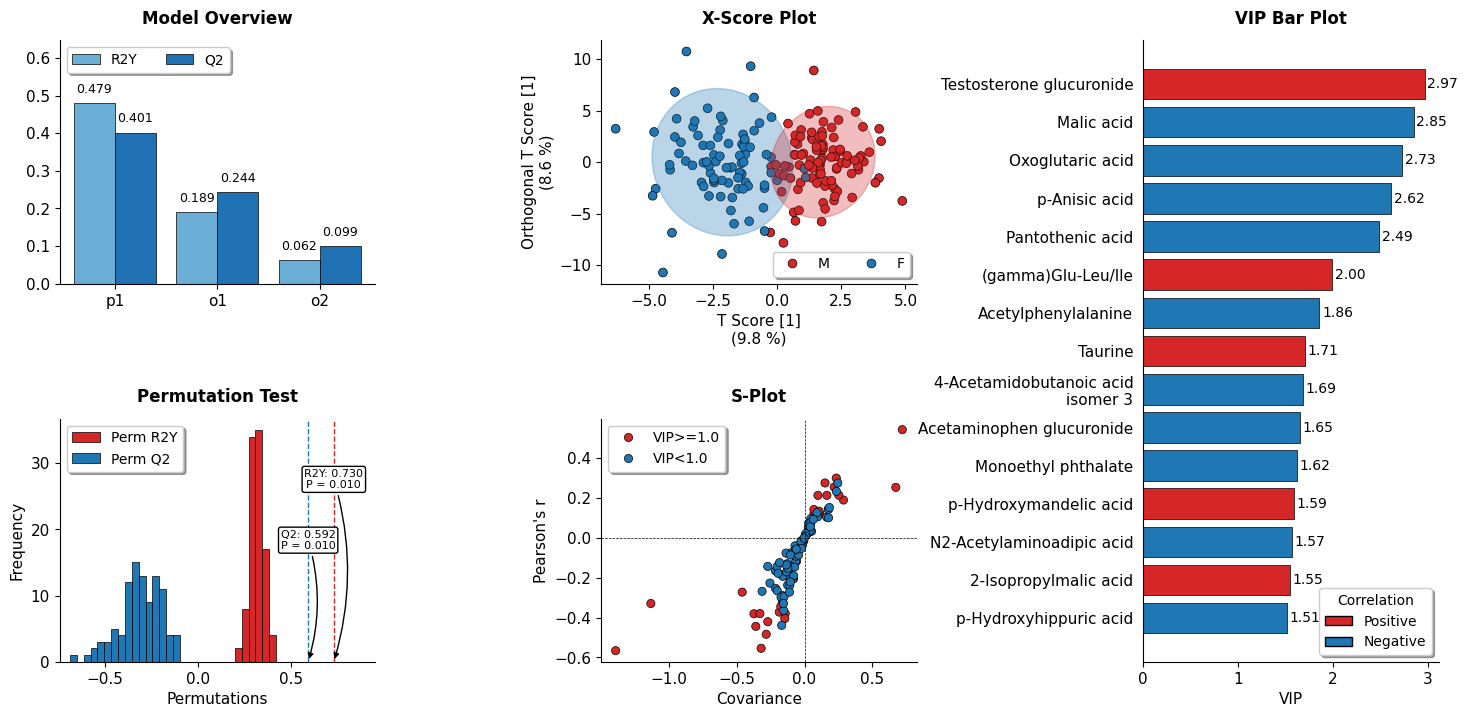

In [5]:
# Generate and display all diagnostic plots in a unified grid layout.
# We pass the perm_results to enable the Permutation plot.
# wrap_width handles long metabolite names in the VIP plot automatically.
# figsize can be explicitly set to fit specific journal column widths.
vis_opls.plot_all(
    perm_results=perm_results, 
    wrap_width=30,
    figsize=(14.5, 7)
)


### 2.4 Advanced: Plotting and Customizing Individual Subplots
Sometimes, you may want to extract a single plot (e.g., the VIP Bar Plot or the Score Plot) for a specific main figure in your manuscript, and apply highly localized stylistic changes without affecting the global default theme.

Because `pi-oplsda` is built purely on an Object-Oriented Matplotlib architecture, you can pass a specific `ax` (axes object) to any plotting function and manually override its properties.

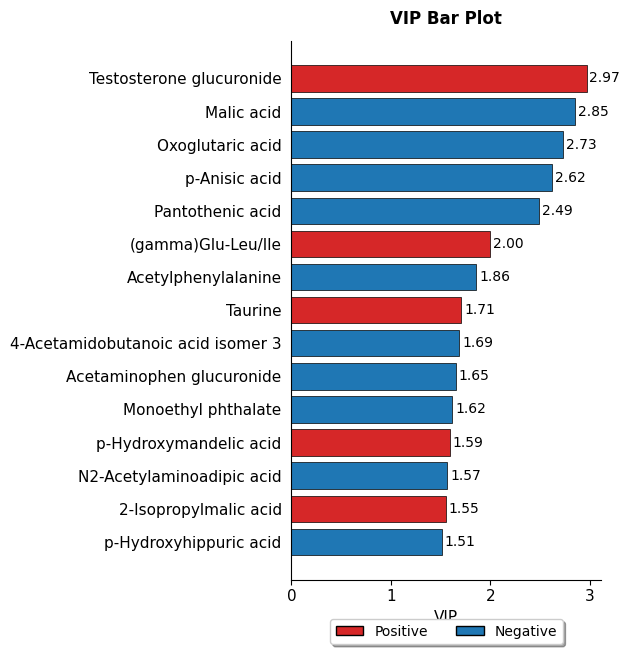

In [6]:
import matplotlib.pyplot as plt

# =====================================================================
# Example A: Standalone VIP Plot with custom Legend repositioning
# =====================================================================

# 1. Create a standalone figure with a specific tall aspect ratio
fig_vip, ax_vip = plt.subplots(figsize=(4, 7))

# 2. Plot ONLY the VIP bar chart on this axis
vis_opls.plot_vip_bar(ax=ax_vip, wrap_width=45)

# 3. Advanced Customization: Extract the default legend and move it outside
old_legend = ax_vip.get_legend()
if old_legend is not None:
    handles = old_legend.legend_handles
    labels = [text.get_text() for text in old_legend.get_texts()]
    title = old_legend.get_title().get_text()
    
    # Re-draw the legend, forcing it to be a 2-column horizontal layout 
    # anchored at the bottom-center, outside the main plotting area.
    ax_vip.legend(
        handles=handles,
        labels=labels,
        title="",
        loc='upper center',          
        bbox_to_anchor=(0.5, -0.06), # X=0.5 (center), Y=-0.06 (below bottom edge)
        ncol=2,                      
        frameon=True, 
        shadow=True, 
        fontsize=10, 
        facecolor="white"
    )


plt.show()

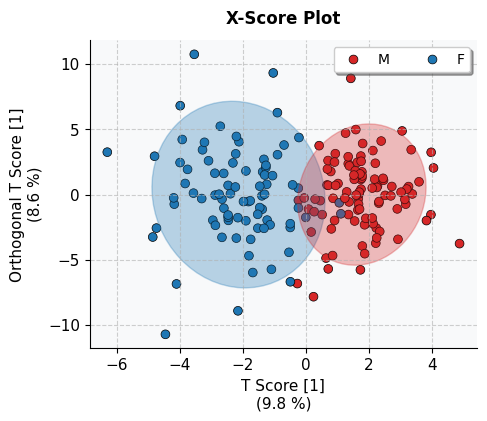

In [7]:
# =====================================================================
# Example B: Standalone Score Plot with local style modifications
# =====================================================================

fig_score, ax_score = plt.subplots(figsize=(5, 4))

# Plot ONLY the Score Scatter plot
vis_opls.plot_score(ax=ax_score)

# Local Override 1: Add grid lines (which are absent by default)
ax_score.grid(True, linestyle='--', alpha=0.6, zorder=0)

# Local Override 2: Add a subtle background color specifically for this plot
ax_score.set_facecolor('#f8f9fa')

plt.show()